In [ ]:
import pyzx as zx
import numpy as np
qubit_amount = 5
gate_count = 80
#Generate random circuit of Clifford gates
circuit = zx.generate.cliffordT(qubit_amount, gate_count)
circuit.add_gate("CNOT", 0, 1)
#If running in Jupyter, draw the circuit
zx.draw(circuit)
#Use one of the built-in rewriting strategies to simplify the circuit
zx.simplify.full_reduce(circuit)
#See the result
zx.draw(circuit)

In [10]:
circuit = zx.Circuit.load("trotter_circuit.qasm")

graph = circuit.to_graph()

zx.draw(graph)

In [17]:
circuit = zx.Circuit.load("trotter_circuit.qasm")

graph = circuit.to_graph()

# zx.simplify.full_reduce(graph)
# zx.draw(graph)

In [7]:
# construct a sequence of z x z measurements 

# Create a new circuit for ZXZ measurements
measurement_circuit = zx.Circuit(2)  # Using 2 qubits for demonstration

# First Z measurement
measurement_circuit.add_gate("ZPhase", 0, phase=np.pi/2)  
measurement_circuit.add_gate("HAD", 0)  # Hadamard gate (H gate)

# X measurement (achieved by applying H gates before and after)
measurement_circuit.add_gate("HAD", 0)  # Change to X basis
measurement_circuit.add_gate("ZPhase", 0, phase=np.pi/2)
measurement_circuit.add_gate("HAD", 0)  # Change back to Z basis

# Second Z measurement
measurement_circuit.add_gate("ZPhase", 0, phase=np.pi/2)

# Draw the measurement sequence
zx.draw(measurement_circuit)




In [7]:
rotate = zx.Graph()
v1 = rotate.add_vertex(zx.VertexType.Z, qubit=0, row=1, phase=1)
v2 = rotate.add_vertex(zx.VertexType.Z, qubit=0, row=1, phase=1)
rotate.add_edge(rotate.edge(v1,v2),edgetype=zx.EdgeType.SIMPLE)

# draw the diagram
zx.draw(rotate)




In [9]:
import pyzx as zx
import numpy as np
import matplotlib.pyplot as plt

# Create a new graph
g = zx.Graph()

# Add input and output boundary vertices for two qubits
inputs = [g.add_vertex(zx.VertexType.BOUNDARY, 0, i) for i in range(2)]
outputs = [g.add_vertex(zx.VertexType.BOUNDARY, 1, i) for i in range(2)]
g.set_inputs(inputs)
g.set_outputs(outputs)

# Prepare magic state |T⟩ = (|0⟩ + e^{iπ/4}|1⟩)/√2 on qubit 0
# Hadamard (Z-spider with π/2) then Z(π/4)
v0 = g.add_vertex(zx.VertexType.Z, 0.5, 0)
g.add_edge((inputs[0], v0), 2)  # Hadamard edge for H
g.set_phase(v0, np.pi/2)
v1 = g.add_vertex(zx.VertexType.Z, 1.0, 0)
g.add_edge((v0, v1))
g.set_phase(v1, np.pi/4)

# Target qubit (qubit 1) just passes through for now
v2 = g.add_vertex(zx.VertexType.Z, 0.5, 1)
g.add_edge((inputs[1], v2))

# CNOT: control=magic (qubit 0), target=target (qubit 1)
# CNOT in ZX: Z-spider (control), X-spider (target), connected
ctrl = g.add_vertex(zx.VertexType.Z, 1.5, 0)
g.add_edge((v1, ctrl))
tgt = g.add_vertex(zx.VertexType.X, 1.5, 1)
g.add_edge((v2, tgt))
g.add_edge((ctrl, tgt))

# Hadamard on magic qubit before measurement (Z-spider with π/2, Hadamard edge)
v3 = g.add_vertex(zx.VertexType.Z, 2.0, 0)
g.add_edge((ctrl, v3), 2)
g.set_phase(v3, np.pi/2)

# Connect to outputs
g.add_edge((v3, outputs[0]))
g.add_edge((tgt, outputs[1]))

# draw 
zx.draw(g)


In [342]:
# susan = zx.Graph()
# susan.add_vertex(zx.VertexType.BOUNDARY, 0, 0) #0
# susan.add_vertex(zx.VertexType.BOUNDARY, 1, 0) #1
# susan.add_vertex(zx.VertexType.BOUNDARY, 0, 5) #2
# susan.add_vertex(zx.VertexType.BOUNDARY, 1, 5) #3
# susan.add_vertex(zx.VertexType.Z, 0, 1) #4
# susan.add_edge((0, 4))
# susan.add_edge((4, 2))
# susan.add_vertex(zx.VertexType.X, 2, 0) #5
# susan.add_vertex(zx.VertexType.X, 2, 1) #6
# susan.add_edge((5, 6))
# susan.add_edge((4, 6))
# susan.add_vertex(zx.VertexType.Z, 1, 2) #7
# susan.add_edge((1, 7))
# susan.add_edge((7, 3))
# susan.add_vertex(zx.VertexType.X, 2, 2) #8
# susan.add_edge((6, 8))
# susan.add_edge((7, 8))
# susan.add_vertex(zx.VertexType.X, 2, 3) #9
# susan.add_edge((8, 9))


# # reduce susan
# zx.simplify.full_reduce(susan)
# zx.draw(susan)
# Create optimized graph
susan_opt = zx.Graph()

# Add boundary vertices more concisely
boundaries = [(0,0), (1,0), (0,5), (1,5)]
b_verts = [susan_opt.add_vertex(zx.VertexType.BOUNDARY, x, y) for x,y in boundaries]

# Add internal vertices
z1 = susan_opt.add_vertex(zx.VertexType.Z, 0, 1)
x1 = susan_opt.add_vertex(zx.VertexType.X, 2, 0) 
x2 = susan_opt.add_vertex(zx.VertexType.X, 2, 1)
z2 = susan_opt.add_vertex(zx.VertexType.Z, 1, 2)
x3 = susan_opt.add_vertex(zx.VertexType.X, 2, 2)
x4 = susan_opt.add_vertex(zx.VertexType.X, 2, 3)

# Add edges more efficiently
edges = [
    (b_verts[0], z1), (z1, b_verts[2]),  # First Z spider connections
    (x1, x2), (z1, x2),                   # First X spider connections
    (b_verts[1], z2), (z2, b_verts[3]),   # Second Z spider connections
    (x2, x3), (z2, x3), (x3, x4)          # Remaining X spider connections
]

for e in edges:
    susan_opt.add_edge(e)

# Reduce susan
zx.simplify.full_reduce(susan_opt)
zx.draw(susan_opt)




In [1]:
import pyzx as zx
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import re


def zz_measurement(qubits):
    # Create a graph directly instead of a circuit
    g = zx.Graph()
    
    # Add input vertices
    inputs = [g.add_vertex(zx.VertexType.BOUNDARY, i, 0) for i in range(qubits)]
    # add a z vertex
    z = g.add_vertex(zx.VertexType.Z, 2, 1)
    inputs.append(z)
    
    g.set_inputs(inputs)

    # add edge 
    g.add_edge((inputs[2], z))
    
    # Add CNOT gates for ZZ measurement
    # First CNOT: control=0, target=2
    ctrl1 = g.add_vertex(zx.VertexType.Z, 0, 2)
    tgt1 = g.add_vertex(zx.VertexType.X, 2, 2)
    g.add_edge((inputs[0], ctrl1))
    g.add_edge((inputs[2], tgt1))
    g.add_edge((ctrl1, tgt1))
    
    # Second CNOT: control=1, target=2
    ctrl2 = g.add_vertex(zx.VertexType.Z, 1, 3)
    tgt2 = g.add_vertex(zx.VertexType.X, 2, 3)
    g.add_edge((inputs[1], ctrl2))
    g.add_edge((tgt1, tgt2))
    g.add_edge((ctrl2, tgt2))
    
    # Add output vertices for unmeasured qubits
    
    outputs = [g.add_vertex(zx.VertexType.BOUNDARY, i, 4) for i in range(qubits-1)]
    out = g.add_vertex(zx.VertexType.Z, 2, 4)
    outputs.append(out)
    g.set_outputs(outputs)
    
    # Connect to outputs
    g.add_edge((ctrl1, outputs[0]))  # Connect qubit 0 to output
    g.add_edge((ctrl2, outputs[1]))  # Connect qubit 1 to output
    g.add_edge((tgt2, outputs[2]))

    
    # # Add measurement vertex for qubit 2
    # meas = g.add_vertex(zx.VertexType.Z, 2)
    # g.add_edge((tgt2, meas))
    
    return g

# Create and visualize the circuit
graph = zz_measurement(3)

zx.draw(graph)

In [44]:
zx.simplify.full_reduce(graph)
zx.draw(graph)

In [ ]:
# rotate,-8,z,x,x,x,z,y,y,y,x,y,
sequence  = ['z', 'x', 'x', 'x', 'x', 'z', 'y', 'y', 'y', 'x', 'y', 'rs0', 'rs1', 'rs2', 'ancilla']
# we need 10 + 3 (y resource states) + 1 (ancilla) = 14 qubits 
g = zx.graph()
cnot_edges_zz = [(0,)]

In [52]:
import pyzx as zx

# rotate,-8,z,x,x,x,z,y,y,y,x,y,
sequence  = ['z', 'x', 'x', 'x', 'x', 'z', 'y', 'y', 'y', 'x', 'y', 'rs', 'rs', 'rs', 'ancilla']
# we need 10 + 3 (y resource states) + 1 (ancilla) = 14 qubits 
cnot_edges_zy = []
cnot_edges_x = []
# add edges between all the 'z' vertices an ancilla and 'y' and ancilla
for i in range(len(sequence)):
    if sequence[i] == 'z' or sequence[i] == 'y' or sequence[i] == 'rs':
        cnot_edges_zy.append((i, len(sequence)-1))
    if sequence[i] == 'x' or sequence[i] == 'y':
        cnot_edges_x.append((len(sequence)-1, i))


print(cnot_edges_zy)
print(cnot_edges_x)

def pauli_product_rot(sequence):
    g = zx.Graph()
    # z = g.add_vertex(zx.VertexType.Z, 2, 1)
    # add boundary vertices
    for i in range(len(sequence)):
        g.add_vertex(zx.VertexType.BOUNDARY, i, 1)

    # add edges between all the 'z' vertices an ancilla and 'y' and ancilla
    for i in range(len(sequence)):
        if sequence[i] == 'z' or sequence[i] == 'y' or sequence[i] == 'rs':
            g.add_edge((i, len(sequence)-1))
        if sequence[i] == 'x' or sequence[i] == 'y':
            g.add_edge((len(sequence)-1, i))

    return g

zx.draw(pauli_product_rot(sequence=sequence))


[(0, 14), (5, 14), (6, 14), (7, 14), (8, 14), (10, 14), (11, 14), (12, 14), (13, 14)]
[(14, 1), (14, 2), (14, 3), (14, 4), (14, 6), (14, 7), (14, 8), (14, 9), (14, 10)]


In [9]:
c1 = zx.Circuit(1)
c1.add_gate('Z', 0)
g1 = c1.to_basic_gates().to_graph()
print(g1.edges)

<bound method GraphS.edges of Graph(3 vertices, 2 edges)>


In [159]:
# one node should not be connected by more that 4 edges 
import pyzx as zx
# rotate,-8,z,x,x,x,z,y,y,y,x,y,
sequence  = ['z', 'x', 'x', 'x', 'x', 'z', 'y', 'y', 'y', 'x', 'y', 'rs', 'rs', 'rs', 'ancilla']
# we need 10 + 3 (y resource states) + 1 (ancilla) = 14 qubits 
cnot_edges_zy = []
cnot_edges_x = []
# add edges between all the 'z' vertices an ancilla and 'y' and ancilla
for i in range(len(sequence)):
    if sequence[i] == 'z' or sequence[i] == 'y' or sequence[i] == 'rs':
        cnot_edges_zy.append((i, 13))  # ancilla is at index 13
    if sequence[i] == 'x' or sequence[i] == 'y':
        cnot_edges_x.append((13, i))  # ancilla is at index 13

print(cnot_edges_zy)      
c = zx.Circuit(14)
for i in range(len(cnot_edges_zy)):
    c.add_gate('CNOT', cnot_edges_zy[i][0], cnot_edges_zy[i][1])
c.add_gate('H', 13)
for i in range(len(cnot_edges_x)):
    c.add_gate('CNOT', cnot_edges_x[i][0], cnot_edges_x[i][1])
zx.draw(c)
g = c.to_basic_gates().to_graph()

[(0, 13), (5, 13), (6, 13), (7, 13), (8, 13), (10, 13), (11, 13), (12, 13), (13, 13)]


In [34]:
# Count and print edges
# print("ZY edges:", cnot_edges_zy)
from pyzx import extract_circuit


print("X edges:", cnot_edges_x)

# Count edges per vertex
vertex_edges = {}
for edge in cnot_edges_x:
    v1, v2 = edge
    vertex_edges[v1] = vertex_edges.get(v1, 0) + 1
    vertex_edges[v2] = vertex_edges.get(v2, 0) + 1

print("\nEdge count per vertex:")
for vertex, count in sorted(vertex_edges.items()):
    print(f"Vertex {vertex}: {count} edges")
    if count > 4:
       new_vertex = g.add_vertex(zx.VertexType.X, vertex, 1)
       g.add_edge((vertex, new_vertex))
        
print(g)
# graph to circuit 
c = extract_circuit(g)
zx.draw(c)


X edges: [(13, 1), (13, 2), (13, 3), (13, 4), (13, 6), (13, 7), (13, 8), (13, 9), (13, 10)]

Edge count per vertex:
Vertex 1: 1 edges
Vertex 2: 1 edges
Vertex 3: 1 edges
Vertex 4: 1 edges
Vertex 6: 1 edges
Vertex 7: 1 edges
Vertex 8: 1 edges
Vertex 9: 1 edges
Vertex 10: 1 edges
Vertex 13: 9 edges
Graph(66 vertices, 69 edges)


In [ ]:
# so, in my circuit, i have 8 cnot connections to the anciilla, so i neede 
# to split my ancilla vertex into 8/2 = 4 new vertices. 
# the middle vertices has 4 connections 
# the two end vertices has 3 connections. 
# out of 3 connections, two goes to 2 differnet yellow nodes, one goes to the adjecent blue node 

In [36]:
pip install networkx

  Using cached networkx-3.1-py3-none-any.whl.metadata (5.3 kB)
Using cached networkx-3.1-py3-none-any.whl (2.1 MB)
Note: you may need to restart the kernel to use updated packages.


In [123]:
g1 = zx.Graph()
# boundary_vertices1 = [g1.add_vertex(zx.VertexType.BOUNDARY, i, 0) for i in range(1, 9)] 

# print(type(boundary_vertices1))
yellow_vertices_left = [g1.add_vertex(zx.VertexType.X, i, 1) for i in range(1, 5)]
blue_vertices = [g1.add_vertex(zx.VertexType.Z, i, 2) for i in range(1, 5)]
yellow_vertices_right = [g1.add_vertex(zx.VertexType.X, i, 3) for i in range(1, 5)]
# boundary_vertices2 = [g1.add_vertex(zx.VertexType.BOUNDARY, i, 4) for i in range(1, 9)]


print(yellow_vertices_left)
print(blue_vertices)
print(yellow_vertices_right)

bridge_node_yellow = g1.add_vertex(zx.VertexType.X, 5, 4)
# bridge_node_yellow_index = g1.add_vertex_indexed(30) # i can give qubit index here    
# print(bridge_node_yellow_index)

# boundary_vertices3 = [g1.add_vertex(zx.VertexType.BOUNDARY, i, 5) for i in range(1, 9)]
blue_vertices_left = [g1.add_vertex(zx.VertexType.Z, i, 6) for i in range(1, 5)]
yellow_vertices = [g1.add_vertex(zx.VertexType.X, i, 7) for i in range(1, 5)]
blue_vertices_right = [g1.add_vertex(zx.VertexType.Z, i, 8) for i in range(1, 5)]
# boundary_vertices4 = [g1.add_vertex(zx.VertexType.BOUNDARY, i, 9) for i in range(1, 9)]
print('g1.vertices', g1.vertices())
for i in range(len(blue_vertices) - 1):
    g1.add_edge((blue_vertices[i], blue_vertices[i + 1]))

for i, blue in enumerate(blue_vertices):
    g1.add_edge((blue, yellow_vertices_left[i]))
    g1.add_edge((blue, yellow_vertices_right[i]))

# add the hadamard port between the bridge node and last blue node
g1.add_edge((bridge_node_yellow, blue_vertices[-1]), edgetype=zx.EdgeType.HADAMARD)
# add normal edge between the bridge node and the last yellow node
g1.add_edge((bridge_node_yellow, yellow_vertices[-1]))

for i in range(len(yellow_vertices) - 1):
    g1.add_edge((yellow_vertices[i], yellow_vertices[i + 1]))

for i, yellow in enumerate(yellow_vertices):
    g1.add_edge((yellow, blue_vertices_right[i]))
    g1.add_edge((yellow, blue_vertices_left[i]))



# Define groups: (boundary_vertices, target_vertices)
# groups = [
#     (boundary_vertices1, yellow_vertices_left),
#     (boundary_vertices2, yellow_vertices_right),
#     (boundary_vertices3, blue_vertices_left),
#     (boundary_vertices4, blue_vertices_right)
# ]

# # Add edges for each group
# for boundary, targets in groups:
#     for i in range(len(targets)):
#         v1 = boundary[2 * i]
#         v2 = boundary[2 * i + 1]
#         g1.add_edge((v1, targets[i]))
#         g1.add_edge((v2, targets[i]))





zx.draw(g1)


# simplify the graph
# zx.simplify.full_reduce(g1)
# zx.draw(g1)


[0, 1, 2, 3]
[4, 5, 6, 7]
[8, 9, 10, 11]
g1.vertices dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])


In [170]:
# write a one to one mapping from my list of vertices to the above graph vertices
# mapping = dict(0:0, 1:3, 2:6, 3:9, 4:2, 5:5, 6:7, 7:10, 8:2, 9:5, 10:8, 11: 11, 12: 12, 13: 13, 14: 16, 15:19, 
#                16: 22, 17:14, 18: 17, 19: 20, 20: 23, 21:15, 22:18, 23:21, 24:24 )
# first one is graphs index, second one is active volume index
keys = list(range(25))
values = [0, 3, 6, 9, 1, 4, 7, 10, 2, 5, 8, 11, 12, 13, 16, 19, 22, 14, 17, 20, 23, 15, 18, 21, 24]

mapping = dict(zip(values, keys))

print(mapping)
# rearrange the mapping with ascending order of keys 
mapping = dict(sorted(mapping.items(), key=lambda item: item[0]))
print(mapping) # this mapping has first elements as the active volume index and second elements as the graph index 

# extract the values
values1 = list(mapping.values())
print(values1)
print(len(values1)//2)


{0: 0, 3: 1, 6: 2, 9: 3, 1: 4, 4: 5, 7: 6, 10: 7, 2: 8, 5: 9, 8: 10, 11: 11, 12: 12, 13: 13, 16: 14, 19: 15, 22: 16, 14: 17, 17: 18, 20: 19, 23: 20, 15: 21, 18: 22, 21: 23, 24: 24}
{0: 0, 1: 4, 2: 8, 3: 1, 4: 5, 5: 9, 6: 2, 7: 6, 8: 10, 9: 3, 10: 7, 11: 11, 12: 12, 13: 13, 14: 17, 15: 21, 16: 14, 17: 18, 18: 22, 19: 15, 20: 19, 21: 23, 22: 16, 23: 20, 24: 24}
[0, 4, 8, 1, 5, 9, 2, 6, 10, 3, 7, 11, 12, 13, 17, 21, 14, 18, 22, 15, 19, 23, 16, 20, 24]
12


In [173]:
# print(cnot_edges_zy)
cnot_edges_zy_first = [cnot_edges_zy[i][0] for i in range(len(cnot_edges_zy) - 1)]

cnot_edges_zy_left = [cnot_edges_zy_first[i] for i in range(len(cnot_edges_zy_first)) if i % 2 == 0]
cnot_edges_zy_right = [cnot_edges_zy_first[i] for i in range(len(cnot_edges_zy_first)) if i % 2 == 1]
# print(cnot_edges_zy_left)
# print(cnot_edges_zy_right)

class Hexagon:
    def __init__(self, index):
        self.index = index
        self.ports = {d: None for d in ['up', 'down', 'north', 'south', 'east', 'west']}

    def connect(self, direction, neighbor_index):
        self.ports[direction] = neighbor_index

# print(Hexagon(0))
# k = Hexagon(0)
# k.connect('up', 1)
# print(k.ports)

direction = ['up', 'down', 'north', 'south', 'east', 'west']
sequence_i_want = []
# print(list(g1.vertices()))
for i in values1:
    n_neighbours = list(g1.neighbors(i))
    # print(i, n_neighbours)
    hexagon = Hexagon(i) # i is the active volume index
    if len(n_neighbours) == 1 and i < len(values1)//2:
        hexagon.connect('up', cnot_edges_zy_left[0])
        hexagon.connect('down', cnot_edges_zy_left[0])
        hexagon.connect('south', n_neighbours[0])
    elif len(n_neighbours) == 1 and i > len(values1)//2:
        hexagon.connect('up', cnot_edges_zy_right[0])
        hexagon.connect('down', cnot_edges_zy_right[0])
        hexagon.connect('north', n_neighbours[0])
    elif len(n_neighbours) == 2 and i < len(values1)//2:
        hexagon.connect('north', n_neighbours[0])
        hexagon.connect('south', n_neighbours[1])
    elif len(n_neighbours) == 2 and i > len(values1)//2:
        hexagon.connect('south', n_neighbours[0])
        hexagon.connect('north', n_neighbours[1])
    elif len(n_neighbours) == 3 and i < len(values1)//2:
        hexagon.connect('east', n_neighbours[0])
        hexagon.connect('north', n_neighbours[1])
        hexagon.connect('south', n_neighbours[2])
    elif len(n_neighbours) == 3 and i > len(values1)//2:
        hexagon.connect('west', n_neighbours[0])
        hexagon.connect('south', n_neighbours[1])
        hexagon.connect('north', n_neighbours[2])
    elif len(n_neighbours) == 4 and i < len(values1)//2:
        hexagon.connect('west', n_neighbours[0])
        hexagon.connect('east', n_neighbours[1])
        hexagon.connect('north', n_neighbours[2])
        hexagon.connect('south', n_neighbours[3])
    elif len(n_neighbours) == 4 and i > len(values1)//2:
        hexagon.connect('east', n_neighbours[0])
        hexagon.connect('west', n_neighbours[1])
        hexagon.connect('south', n_neighbours[2])
        hexagon.connect('north', n_neighbours[3])
    sequence_i_want.append(hexagon)

print(sequence_i_want[2].ports)








{'up': 0, 'down': 0, 'north': None, 'south': 4, 'east': None, 'west': None}


In [234]:
print(len(values1)//2)

12


In [ ]:
# one way: you can modify the sequence in which your nodes are connected

/var/folders/zy/nv6qy3ws6fg2r6cm9d4gb6rh0000gn/T/ipykernel_25576/1696888818.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


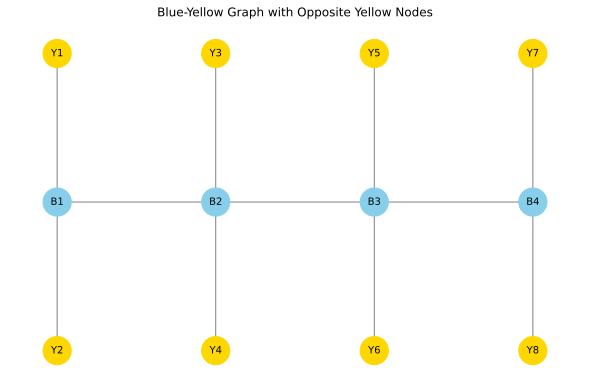

In [38]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.Graph()

# Blue and Yellow nodes
blue_nodes = [f'B{i}' for i in range(1, 5)]
yellow_nodes = [f'Y{i}' for i in range(1, 9)]

G.add_nodes_from(blue_nodes + yellow_nodes)

# Add edges between blue nodes (nearest neighbors)
for i in range(len(blue_nodes) - 1):
    G.add_edge(blue_nodes[i], blue_nodes[i + 1])

# Add edges from each blue node to two yellow nodes
for i, blue in enumerate(blue_nodes):
    y_top = yellow_nodes[2 * i]
    y_bottom = yellow_nodes[2 * i + 1]
    G.add_edges_from([(blue, y_top), (blue, y_bottom)])

# Positioning nodes
pos = {}
for i, blue in enumerate(blue_nodes):
    x = i
    pos[blue] = (x, 0)                           # Blue nodes on center line
    pos[yellow_nodes[2 * i]] = (x, 1)            # Top yellow node
    pos[yellow_nodes[2 * i + 1]] = (x, -1)       # Bottom yellow node

# Define node colors
node_colors = ['skyblue' if node.startswith('B') else 'gold' for node in G.nodes()]

# Draw the graph
plt.figure(figsize=(8, 5))
nx.draw(
    G, pos, with_labels=True, node_color=node_colors,
    node_size=800, font_size=10, edge_color='gray'
)
plt.title("Blue-Yellow Graph with Opposite Yellow Nodes")
plt.axis('off')
plt.tight_layout()
plt.show()



In [276]:
print(cnot_edges_zy)
cnot_edges_zy_control = [cnot_edges_zy[i][0]+1 for i in range(len(cnot_edges_zy) - 1)]

print('yellow_index_left', yellow_index_left)
print('cnot_edges_zy_control', cnot_edges_zy_control)

cnot_edges_zy_control_left = [cnot_edges_zy_control[i] for i in range(len(cnot_edges_zy_control)) if i % 2 == 0]
cnot_edges_zy_control_right = [cnot_edges_zy_control[i] for i in range(len(cnot_edges_zy_control)) if i % 2 == 1]
print('cnot_edges_zy_control_left', cnot_edges_zy_control_left)
print('cnot_edges_zy_control_right', cnot_edges_zy_control_right)
print('yellow_index_right', yellow_index_right)

cnot_edges_x_target = [cnot_edges_x[i][1]+1 for i in range(len(cnot_edges_x) - 1)]
print('cnot_edges_x_target', cnot_edges_x_target)

cnot_edges_x_target_left = [cnot_edges_x_target[i] for i in range(len(cnot_edges_x_target)) if i % 2 == 0]
cnot_edges_x_target_right = [cnot_edges_x_target[i] for i in range(len(cnot_edges_x_target)) if i % 2 == 1]
print('cnot_edges_x_target_left', cnot_edges_x_target_left)
print('cnot_edges_x_target_right', cnot_edges_x_target_right)


[(0, 13), (5, 13), (6, 13), (7, 13), (8, 13), (10, 13), (11, 13), (12, 13), (13, 13)]
yellow_index_left [1, 4, 7, 10]
cnot_edges_zy_control [1, 6, 7, 8, 9, 11, 12, 13]
cnot_edges_zy_control_left [1, 7, 9, 12]
cnot_edges_zy_control_right [6, 8, 11, 13]
yellow_index_right [3, 6, 9, 12]
cnot_edges_x_target [2, 3, 4, 5, 7, 8, 9, 10]
cnot_edges_x_target_left [2, 4, 7, 9]
cnot_edges_x_target_right [3, 5, 8, 10]


[2, 5, 8, 11]
[15, 18, 21, 24]
[1, 4, 7, 10]
[3, 6, 9, 12]
[14, 17, 20, 23]
[16, 19, 22, 25]
2 [5, 1, 3]
5 [2, 8, 4, 6]
8 [5, 11, 7, 9]
11 [8, 10, 12, 13]
15 [18, 16, 14]
18 [15, 21, 19, 17]
21 [18, 24, 22, 20]
24 [13, 21, 25, 23]
14 [15]
17 [18]
20 [21]
23 [24]
16 [15]
19 [18]
22 [21]
25 [24]
1 [2]
4 [5]
7 [8]
10 [11]
3 [2]
6 [5]
9 [8]
12 [11]
13 [11, 24]
bridge


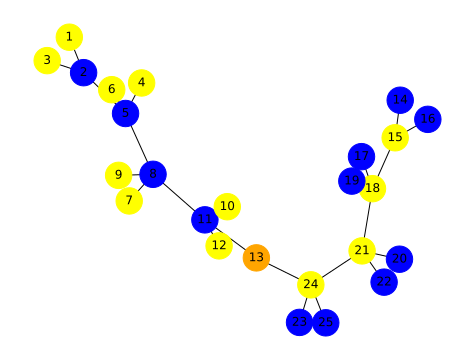

In [277]:
blue_nodes = 4
yellow_nodes = 4 
total_nodes = 6*blue_nodes + 1
blue_index = list(range(2, total_nodes//2 + 1, 3))
bridge_node_index = total_nodes//2 + 1
yellow_index = list(range(bridge_node_index + 2, total_nodes + 1, 3))
print(blue_index)
print(yellow_index)
yellow_index_left = list(range(1, total_nodes//2 + 1, 3))
yellow_index_right = list(range(3, total_nodes//2 + 1, 3))
print(yellow_index_left)
print(yellow_index_right)
blue_index_left = list(range(bridge_node_index + 1, total_nodes + 1, 3))
blue_index_right = list(range(bridge_node_index + 3, total_nodes + 1, 3))
print(blue_index_left)
print(blue_index_right)

G = nx.Graph()
node_attrs = {}

for i in blue_index:
    G.add_node(i)
    node_attrs[i] = {'color': 'blue'}


for i in yellow_index:
    G.add_node(i)
    node_attrs[i] = {'color': 'yellow'}

for i in range(len(blue_index_left)):
    G.add_node(blue_index_left[i])
    node_attrs[blue_index_left[i]] = {'color': 'blue'}
    G.nodes[blue_index_left[i]]['name'] = 'q' + str(cnot_edges_x_target_left[i])

for i in range(len(blue_index_right)):
    G.add_node(blue_index_right[i])
    node_attrs[blue_index_right[i]] = {'color': 'blue'}
    G.nodes[blue_index_right[i]]['name'] = 'q' + str(cnot_edges_x_target_right[i])

for i in range(len(yellow_index_left)):
    G.add_node(yellow_index_left[i])
    node_attrs[yellow_index_left[i]] = {'color': 'yellow'}
    G.nodes[yellow_index_left[i]]['name'] = 'q' + str(cnot_edges_zy_control_left[i])

for i in range(len(yellow_index_right)):
    G.add_node(yellow_index_right[i])
    node_attrs[yellow_index_right[i]] = {'color': 'yellow'}
    G.nodes[yellow_index_right[i]]['name'] = 'q' + str(cnot_edges_zy_control_right[i])


G.add_node(bridge_node_index)
# add name to the bridge node
G.nodes[bridge_node_index]['name'] = 'bridge'
node_attrs[bridge_node_index] = {'color': 'orange'}


for i in range(len(blue_index) - 1):
    G.add_edge(blue_index[i], blue_index[i + 1])

for i, blue in enumerate(blue_index):
    G.add_edge(blue, yellow_index_left[i])
    G.add_edge(blue, yellow_index_right[i])

# add the hadamard port between the bridge node and last blue node
G.add_edge(bridge_node_index, blue_index[-1])
# add normal edge between the bridge node and the last yellow node
G.add_edge(bridge_node_index, yellow_index[-1])

for i in range(len(yellow_index) - 1):
    G.add_edge(yellow_index[i], yellow_index[i + 1])

for i, yellow in enumerate(yellow_index):
    G.add_edge(yellow, blue_index_right[i])
    G.add_edge(yellow, blue_index_left[i])

# Ensure all nodes have a color attribute
colors = []
for n in G.nodes:
    if n in node_attrs and 'color' in node_attrs[n]:
        colors.append(node_attrs[n]['color'])
    else:
        colors.append('gray')  # default color for missing nodes

# get neighbors of each node
for n in G.nodes:
    print(n, list(G.neighbors(n)))
# show the name of bridge node
print(G.nodes[bridge_node_index]['name'])

# Layout and drawing
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=700)
plt.show()


In [235]:
print(len(G.nodes)//2)
print(G.nodes)

12
[2, 5, 8, 11, 15, 18, 21, 24, 14, 17, 20, 23, 16, 19, 22, 25, 1, 4, 7, 10, 3, 6, 9, 12, 13]


In [263]:
print(cnot_edges_zy)
cnot_edges_zy_control = [cnot_edges_zy[i][0]+1 for i in range(len(cnot_edges_zy) - 1)]

print('yellow_index_left', yellow_index_left)
print('cnot_edges_zy_control', cnot_edges_zy_control)


print('yellow_index_right', yellow_index_right)


[(0, 13), (5, 13), (6, 13), (7, 13), (8, 13), (10, 13), (11, 13), (12, 13), (13, 13)]
yellow_index_left [1, 4, 7, 10]
cnot_edges_zy_control [1, 6, 7, 8, 9, 11, 12, 13]
yellow_index_right [3, 6, 9, 12]


In [281]:
# print(cnot_edges_zy)
cnot_edges_zy_first = [cnot_edges_zy[i][0] for i in range(len(cnot_edges_zy) - 1)]

cnot_edges_zy_left = [cnot_edges_zy_first[i] for i in range(len(cnot_edges_zy_first)) if i % 2 == 0]
cnot_edges_zy_right = [cnot_edges_zy_first[i] for i in range(len(cnot_edges_zy_first)) if i % 2 == 1]
print(cnot_edges_zy_left)
print(cnot_edges_zy_right)

class Hexagon:
    def __init__(self, index):
        self.index = index
        self.ports = {d: None for d in ['up', 'down', 'north', 'south', 'east', 'west']}

    def connect(self, direction, neighbor_index):
        self.ports[direction] = neighbor_index

# print(Hexagon(0))
# k = Hexagon(0)
# k.connect('up', 1)
# print(k.ports)

direction = ['up', 'down', 'north', 'south', 'east', 'west']
sequence_i_want = []
# print(list(g1.vertices()))
for i in G.nodes:
    n_neighbours = list(G.neighbors(i))
    # print(i, n_neighbours)
    hexagon = Hexagon(i) # i is the active volume index
    name = G.nodes[i]['name'] if 'name' in G.nodes[i] else None
    if len(n_neighbours) == 1 and i <= len(G.nodes)//2:
        hexagon.connect('up', name)
        hexagon.connect('down', name)
        hexagon.connect('south', n_neighbours[0])
    elif len(n_neighbours) == 1 and i > len(G.nodes)//2:
        hexagon.connect('up', name)
        hexagon.connect('down', name)
        hexagon.connect('north', n_neighbours[0])
    elif len(n_neighbours) == 2 and i < len(G.nodes)//2:
        hexagon.connect('north', n_neighbours[0])
        hexagon.connect('south', n_neighbours[1])
    elif len(n_neighbours) == 2 and i > len(G.nodes)//2:
        hexagon.connect('south', n_neighbours[0])
        hexagon.connect('north', n_neighbours[1])
    elif len(n_neighbours) == 3 and i < len(G.nodes)//2:
        hexagon.connect('east', n_neighbours[0])
        hexagon.connect('north', n_neighbours[1])
        hexagon.connect('south', n_neighbours[2])
    elif len(n_neighbours) == 3 and i > len(G.nodes)//2:
        hexagon.connect('west', n_neighbours[0])
        hexagon.connect('south', n_neighbours[1])
        hexagon.connect('north', n_neighbours[2])
    elif len(n_neighbours) == 4 and i < len(G.nodes)//2:
        hexagon.connect('west', n_neighbours[0])
        hexagon.connect('east', n_neighbours[1])
        hexagon.connect('north', n_neighbours[2])
        hexagon.connect('south', n_neighbours[3])
    elif len(n_neighbours) == 4 and i > len(G.nodes)//2:
        hexagon.connect('east', n_neighbours[0])
        hexagon.connect('west', n_neighbours[1])
        hexagon.connect('south', n_neighbours[2])
        hexagon.connect('north', n_neighbours[3])
    sequence_i_want.append(hexagon)
    if i == len(G.nodes)//2 + 1:
        hexagon.connect('up', name)


print('logical block:',sequence_i_want[0].index, ',' , 'ports:', sequence_i_want[0].ports)


for i in sequence_i_want:
    print(i.index, i.ports)




[0, 6, 8, 11]
[5, 7, 10, 12]
logical block: 2 , ports: {'up': None, 'down': None, 'north': 1, 'south': 3, 'east': 5, 'west': None}
2 {'up': None, 'down': None, 'north': 1, 'south': 3, 'east': 5, 'west': None}
5 {'up': None, 'down': None, 'north': 4, 'south': 6, 'east': 8, 'west': 2}
8 {'up': None, 'down': None, 'north': 7, 'south': 9, 'east': 11, 'west': 5}
11 {'up': None, 'down': None, 'north': 12, 'south': 13, 'east': 10, 'west': 8}
15 {'up': None, 'down': None, 'north': 14, 'south': 16, 'east': None, 'west': 18}
18 {'up': None, 'down': None, 'north': 17, 'south': 19, 'east': 15, 'west': 21}
21 {'up': None, 'down': None, 'north': 20, 'south': 22, 'east': 18, 'west': 24}
24 {'up': None, 'down': None, 'north': 23, 'south': 25, 'east': 13, 'west': 21}
14 {'up': 'q2', 'down': 'q2', 'north': 15, 'south': None, 'east': None, 'west': None}
17 {'up': 'q4', 'down': 'q4', 'north': 18, 'south': None, 'east': None, 'west': None}
20 {'up': 'q7', 'down': 'q7', 'north': 21, 'south': None, 'east': N

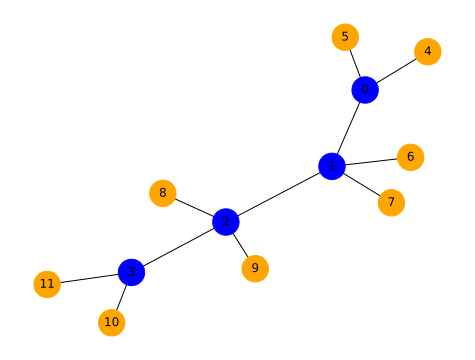

In [174]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

n = 4  # Number of core (blue) nodes
core_nodes = list(range())  # Blue nodes: 0 to 3
yellow_id = n  # Start yellow node IDs after blue nodes

# Keep track of node attributes
node_attrs = {}

# Add core (blue) nodes
for i in core_nodes:
    G.add_node(i)
    node_attrs[i] = {'color': 'blue'}

# Add connections
for i in core_nodes:
    # Add 2 yellow neighbors per core node
    for _ in range(2):
        yellow_node = yellow_id
        G.add_node(yellow_node)
        node_attrs[yellow_node] = {'color': 'orange'}
        G.add_edge(i, yellow_node)
        yellow_id += 1

    # Add internal edge(s) between adjacent core nodes
    if i < n - 1:
        G.add_edge(i, i + 1)

# Apply attributes
colors = [node_attrs[n]['color'] for n in G.nodes]

# Layout and drawing
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=700)
plt.show()


In [1]:
pip install nwqec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 7.5 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import nwqec

circuit = nwqec.load_qasm("/Users/jgh407/Documents/github/zx_compiler/trotter_circuit.qasm")
print(circuit.stats())

clifford_t = nwqec.to_clifford_t(circuit, keep_ccx=False, epsilon=1e-10)
print("WITH_GRIDSYNTH_CPP:", nwqec.WITH_GRIDSYNTH_CPP)
print("Clifford+T gate counts:", clifford_t.count_ops())

# Pauli-Based Circuit + Tfuse
pbc = nwqec.to_pbc(circuit)
pbc_opt = nwqec.fuse_t(pbc)
print("T count before Tfuse:", pbc.count_ops().get("t_pauli", 0))
print("T count after Tfuse:", pbc_opt.count_ops().get("t_pauli", 0))

# Clifford reduction optimization
clifford_reduced = nwqec.to_clifford_reduction(circuit)
print(f"Depth reduction over Clifford+T: {clifford_t.depth() / clifford_reduced.depth():.2f}x")
print(f"Depth reduction over PBC: {pbc.depth() / clifford_reduced.depth():.2f}x")

Circuit Statistics
Basic Circuit Information:
  Number of qubits: 10
  Number of classical bits: 0
  Total gates: 6873
  Circuit depth: 6691 gates
  Clifford+T circuit: Yes

Gate Count Breakdown:
    t: 2516
    tdg: 4
    s: 1425
    sdg: 30
    h: 2642
    cx: 256

Derived Statistics:
  Total T-type gates: 2520
  Total two-qubit gates: 256
  T-gate ratio: 36.7%
  Two-qubit gate ratio: 3.7%


WITH_GRIDSYNTH_CPP: True
Clifford+T gate counts: {'cx': 256, 's': 1425, 't': 2516, 'tdg': 4, 'h': 2638, 'sdg': 30}
T count before Tfuse: 2520
T count after Tfuse: 2468
Depth reduction over Clifford+T: 1.61x
Depth reduction over PBC: 0.60x
